# Day 2:  <font color = "red">**Structure → Property Challenge**</font>

Can local image structure predict the local EELS response?

For each location, we have:

**Image patch → EELS spectrum → Scalarizer**

Your task is to:

1. Build a <font color = "yellow">**descriptor**</font> for the image patch.
2. Use a <font color = "yellow">**regressor**</font> to predict a scalarizer or the full spectrum.
3. Compare methods by:
   - predictive power
   - complexity
   - explainability

<font color = "green">**Goal**</font>

> Find the simplest explainable descriptor that predicts the EELS response well.

## 1. Explore the Dataset

Each spatial location contains:

- one image intensity value
- one full EELS spectrum

The same position in the image corresponds to the same position in the EELS spectrum image.

Let's look at one dataset.

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [30]:
file_name = "Plasmonic_sets_hackathon.npy"

raw = np.load(
    file_name,
    allow_pickle=True
)

loadedfile = raw.tolist()
print("keys:", loadedfile.keys())

keys: dict_keys(['0', '1', '2', '3'])


In [33]:
# Choose dataset
data = loadedfile["2"]

image = data["image"]
spectra = data["spectrum image"]
energy = data["energy axis"]

H, W = image.shape

print(image.shape)
print(spectra.shape)
print(energy.shape)

(33, 63)
(33, 63, 4322)
(4322,)


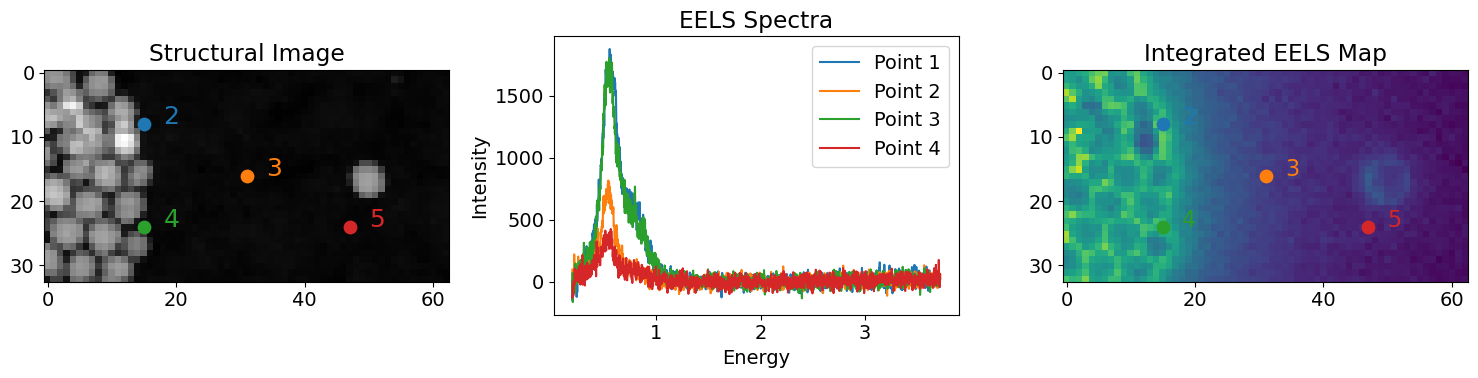

In [34]:
# Example locations
positions = [
    (H // 4, W // 4),
    (H // 2, W // 2),
    (3 * H // 4, W // 4),
    (3 * H // 4, 3 * W // 4),
]

colors = ["C0", "C1", "C2", "C3"]

# Integrated EELS map
eels_map = spectra.sum(axis=2)

plt.rcParams.update({"font.size": 14})

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Structural image
ax[0].imshow(image, cmap="gray")
ax[0].set_title("Structural Image")

# Spectra
for i, ((y, x), color) in enumerate(zip(positions, colors)):
    
    ax[0].scatter(x, y, s=80, color=color)
    ax[0].text(x + 3, y, str(i + 2), color=color, fontsize=18)

    ax[1].plot(
        energy,
        spectra[y, x],
        color=color,
        label=f"Point {i + 1}"
    )

    ax[2].scatter(x, y, s=80, color=color)
    ax[2].text(x + 3, y, str(i + 2), color=color, fontsize=16)

ax[1].set_title("EELS Spectra")
ax[1].set_xlabel("Energy")
ax[1].set_ylabel("Intensity")
ax[1].legend()

# EELS map
ax[2].imshow(eels_map)
ax[2].set_title("Integrated EELS Map")

plt.tight_layout()
plt.show()

## 2. Define a Scalarizer

Each EELS spectrum can be reduced to a **single target value** called a scalarizer.

For example, the spectral intensity within an energy window:

$$
S(x,y)=\int_{E_1}^{E_2} I(x,y,E)\,dE
$$

where \(E_1\) and \(E_2\) define the spectral region of interest.

Other possible scalarizers include:

- peak intensity
- peak position
- peak area
- peak ratio

## 3. Choose a Spectral Region

Before defining the scalarizer, inspect the EELS spectrum and choose an energy range containing a feature of interest.

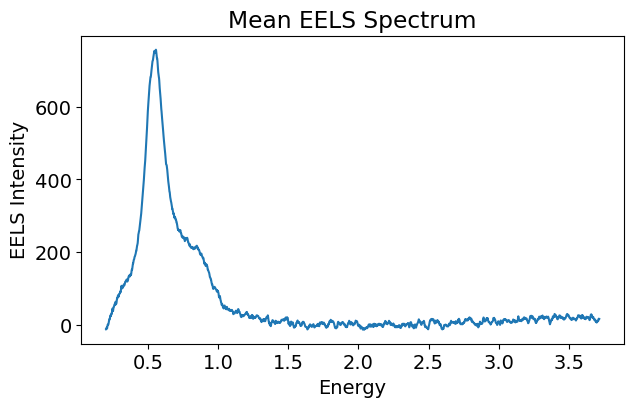

In [37]:
# Mean spectrum over the whole image
mean_spectrum = spectra.mean(axis=(0, 1))

plt.figure(figsize=(7, 4))

plt.plot(energy, mean_spectrum)

plt.xlabel("Energy")
plt.ylabel("EELS Intensity")
plt.title("Mean EELS Spectrum")

plt.show()

## 4. Calculate the Scalarizer

We integrate the EELS intensity inside the selected energy window to obtain one target value at each spatial location.

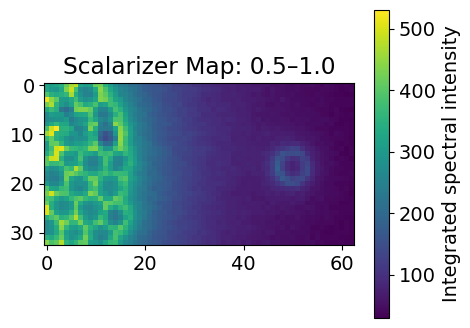

In [39]:
# Choose an energy range
E1 = 0.5
E2 = 1.0

mask = (energy >= E1) & (energy <= E2)

scalarizer_map = np.trapezoid(
    spectra[:, :, mask],
    energy[mask],
    axis=2
)

plt.figure(figsize=(5, 4))
plt.imshow(scalarizer_map)
plt.colorbar(label="Integrated spectral intensity")
plt.title(f"Scalarizer Map: {E1}–{E2}")
plt.show()

## 5. Create Patch–Spectrum–Scalarizer Pairs

For each location we collect:

**Image patch → EELS spectrum → Scalarizer**

The spectrum and scalarizer correspond to the center pixel of the patch.

In [42]:
PATCH_SIZE = 20
half = PATCH_SIZE // 2

patches = []
targets = []

for y in range(half, H - half):
    for x in range(half, W - half):

        patch = image[y-half:y+half+1, x-half:x+half+1]

        patches.append(patch)
        targets.append(scalarizer_map[y, x])

patches = np.array(patches)
targets = np.array(targets)

print("Patches:", patches.shape)
print("Targets:", targets.shape)

Patches: (559, 21, 21)
Targets: (559,)


## 6. Look at Example Pairs

Each patch has one target scalarizer value.

Can you see structural differences between low and high target values?

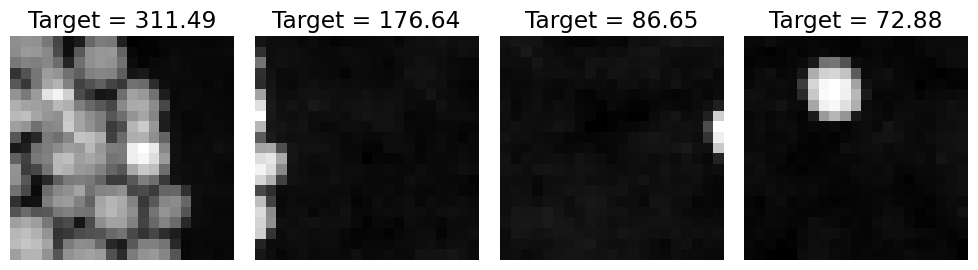

In [43]:
fig, ax = plt.subplots(1, 4, figsize=(10, 3))

ids = np.linspace(0, len(patches) - 1, 4, dtype=int)

for i, idx in enumerate(ids):
    ax[i].imshow(patches[idx], cmap="gray")
    ax[i].set_title(f"Target = {targets[idx]:.2f}")
    ax[i].axis("off")

plt.tight_layout()
plt.show()

## 7. Build a Simple Descriptor

A descriptor converts each image patch into a few numbers.

We will start with:

- mean intensity
- intensity variation
- intensity range

In [44]:
def descriptor(patch):

    return [
        patch.mean(),
        patch.std(),
        patch.max() - patch.min()
    ]

Then convert all patches:

In [45]:
X = np.array([
    descriptor(patch)
    for patch in patches
])

print("Descriptor matrix:", X.shape)

Descriptor matrix: (559, 3)


## 8. Train a Regressor

We now use the descriptor values to predict the EELS scalarizer.

Use a simple regression model to learn:

Descriptor → Scalarizer

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X,
    targets,
    test_size=0.25,
    random_state=0
)

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

## 9. Evaluate the Prediction

We compare the predicted scalarizer values with the true values.

A better model should place the points close to the diagonal line.

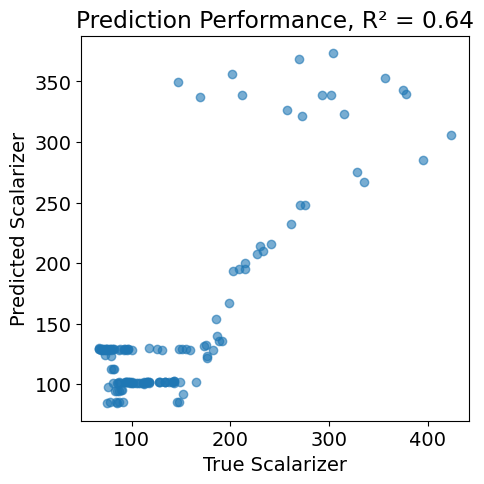

In [47]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)

plt.figure(figsize=(5, 5))

plt.scatter(y_test, predictions, alpha=0.6)

plt.xlabel("True Scalarizer")
plt.ylabel("Predicted Scalarizer")
plt.title(f"Prediction Performance, R² = {r2:.2f}")

plt.show()

10. Your Turn — Build a Better Descriptor

Now improve the descriptor.

Try to find features that are:

- predictive
- simple
- explainable

Examples:

- mean
- standard deviation
- intensity range
- percentiles
- gradients
- edges

In [76]:
def my_descriptor(patch):

    # ============================================================
    # YOUR CODE STARTS HERE
    # ============================================================

    features = [
        patch.min(),
        patch.sum(),
    ]

    # ============================================================
    # YOUR CODE ENDS HERE
    # ============================================================

    return features

Then build the new descriptor matrix:

In [77]:
X_new = np.array([
    my_descriptor(patch)
    for patch in patches
])

print(X_new.shape)

(559, 2)


## 11. Compare Your Descriptor

Train the same regressor using your new descriptor and compare the result with the baseline.

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X_new,
    targets,
    test_size=0.25,
    random_state=0
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions_new = model.predict(X_test)

r2_new = r2_score(y_test, predictions_new)

print(f"Baseline R²: {r2:.2f}")
print(f"New R²:      {r2_new:.2f}")
print(f"Number of features: {X_new.shape[1]}")

Baseline R²: 0.64
New R²:      0.63
Number of features: 2


## 12. Predictive Power vs Complexity

A good descriptor should predict well without becoming unnecessarily complex.

We compare:

- <font color = "yellow">**Predictive power:**</font> R²
- <font color = "yellow">**Complexity:**</font>  number of descriptor features

We will use these results later to build the Pareto front.

In [110]:
results = [
    ["Base", X.shape[1], r2],
    ["D1", X_new.shape[1], r2_new]
]

results

[['Base', 3, 0.6354012517343961], ['D1', 2, 0.6307161068601004]]

## 13. Try Another Descriptor

Try a different set of image features and test it using the same regression model.

In [88]:
def my_descriptor_2(patch):

    # ============================================================
    # YOUR CODE STARTS HERE
    # ============================================================

    features = [
        patch.mean(),
        patch.std(),
        patch.min(),
        patch.max(),
        np.median(patch)
    ]

    # ============================================================
    # YOUR CODE ENDS HERE
    # ============================================================

    return features

Build and test it:

In [89]:
X_2 = np.array([
    my_descriptor_2(patch)
    for patch in patches
])

X_train, X_test, y_train, y_test = train_test_split(
    X_2,
    targets,
    test_size=0.25,
    random_state=0
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions_2 = model.predict(X_test)

r2_2 = r2_score(y_test, predictions_2)

print(f"R²: {r2_2:.2f}")
print(f"Number of features: {X_2.shape[1]}")

R²: 0.81
Number of features: 5


In [111]:
results.append([
    "D2",
    X_2.shape[1],
    r2_2
])

results

[['Base', 3, 0.6354012517343961],
 ['D1', 2, 0.6307161068601004],
 ['D2', 5, 0.8100751157216091]]

## 14. Pareto Front

Now compare all tested descriptors.

We want:

- **higher R²**
- **fewer features**

Points on the Pareto front represent the best tradeoffs.

In [91]:
# Sort by complexity
results = sorted(results, key=lambda x: (x[1], -x[2]))

pareto = []
best_r2 = -np.inf

for result in results:
    if result[2] > best_r2:
        pareto.append(result)
        best_r2 = result[2]

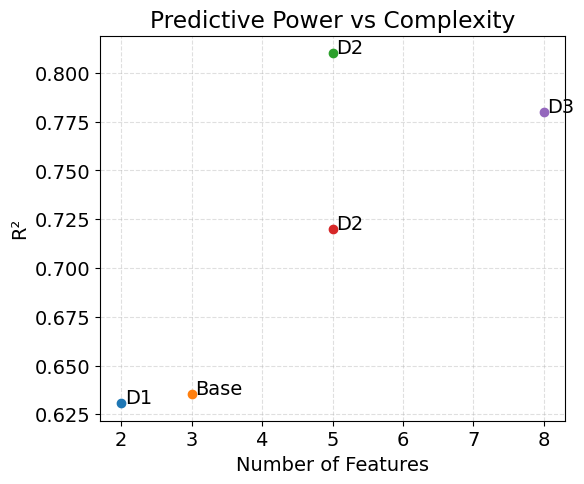

In [107]:
plt.figure(figsize=(6, 5))

# All descriptors
for name, complexity, score in results:
    plt.scatter(complexity, score)
    plt.text(complexity + 0.05, score, name)


plt.xlabel("Number of Features")
plt.ylabel("R²")
plt.title("Predictive Power vs Complexity")

plt.gca().set_axisbelow(True)
plt.grid(alpha=0.4, linestyle="--")

plt.show()

## 15. Explain Your Descriptor

A good descriptor should not only predict well — we should understand what it measures.

Describe:

- What features does your descriptor use?
- Which features seem most important?
- What structural information might they represent?

In [108]:
for i, coef in enumerate(model.coef_):
    print(f"Feature {i+1}: {coef:.3f}")

Feature 1: 58370.824
Feature 2: -31967.848
Feature 3: 114850.414
Feature 4: 2422.542
Feature 5: -25786.816


## 16. Final Result

Report your best descriptor:

- **Descriptor:** What features did you use?
- **Predictive power:** R²
- **Complexity:** Number of features
- **Explainability:** What structural information does it capture?
- **Pareto:** Is your descriptor on the Pareto front?

### Final Question

> What is the simplest explainable image descriptor that predicts the EELS response well?